# Tầng 2 — Phân loại chứng từ & bóc tách trường khóa (KIDO)

Notebook này **không chứa logic phân loại**. Nó import `tools/stage2_classifier.py` và dùng đúng hàm
chấm điểm `run_benchmark()` của `tools/run_full_benchmark_and_save.py` (cùng hàm mà CLI dùng), nên số
liệu ở đây và số liệu CLI là **một phép đo**.

| Mục | Nội dung |
|---|---|
| 1 | Thiết lập, tham số `OUT_DIR` |
| 2 | Cấu hình đang nạp: từ điển + 10 ngưỡng từ `config/stage2_keywords.json`, danh mục mã chuyến |
| 3 | Đầu vào Tầng 1 (`output/stage1_out`); 3b metadata upload (nguồn duy nhất của đồng thuận đa trang) |
| 4 | Phân loại **tất cả** ảnh (mọi loại chứng từ) + ghi artifact |
| 5 | Benchmark so `output/stage2_gt.json`: doc_type, page_role, hệ thống strict + cấp họ, trường khóa P/R, gác cổng |
| 6 | Bảng lỗi từng ca |
| 7 | Tách loại kho `INTERNAL_KHO_THUE` / `INTERNAL_KHO_NOIBO` |
| 8 | Riêng các trang `LOADING_PLAN`: doc_type, hệ thống → kênh chính sách chữ ký Tầng 4 |
| 9 | Hợp đồng artifact: file nào Tầng 3/4 đọc; DIFF với artifact chính thức khi chạy thử |
| 10 | Test bất biến tên file (đổi tên ngẫu nhiên, OCR lại, DIFF = 0 + đối chứng dương) |

> Mọi con số dưới đây được **tính khi chạy**; markdown không ghi sẵn số nào.

## 1. Thiết lập

In [1]:
import os, sys, json, time
from pathlib import Path

# Tìm thư mục dự án (chứa tools/stage2_classifier.py) và chdir vào đó: Stage2Config dùng đường dẫn tương đối.
PROJECT_DIR = Path.cwd().resolve()
while not (PROJECT_DIR / "tools" / "stage2_classifier.py").exists():
    if PROJECT_DIR == PROJECT_DIR.parent:
        raise RuntimeError("Không tìm thấy thư mục dự án (tools/stage2_classifier.py).")
    PROJECT_DIR = PROJECT_DIR.parent
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import cv2
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 80)

import tools.stage2_classifier as s2
from tools.run_full_benchmark_and_save import run_benchmark, FIELDS

# ---- THAM SỐ ----
# Mặc định: artifact CHÍNH THỨC mà Tầng 3/4 đọc. Chạy thử: đặt biến môi trường STAGE2_NB_OUT_DIR
# (hoặc runner `--out-dir`) trỏ ra ngoài output/ để không ghi đè.
OFFICIAL_OUT_DIR = Path("output/stage2_out")
OUT_DIR = Path(os.environ.get("STAGE2_NB_OUT_DIR", str(OFFICIAL_OUT_DIR)))
IS_OFFICIAL_RUN = OUT_DIR.resolve() == OFFICIAL_OUT_DIR.resolve()

from tools.run_full_benchmark_and_save import DEFAULT_UPLOAD_GROUPS_PATH, cfg_for_stage1_dir, load_upload_groups

# Đầu ra Tầng 1: mặc định output/stage1_out; STAGE2_NB_STAGE1_DIR để chạy thử trên bản Tầng 1 khác.
STAGE1_DIR = os.environ.get("STAGE2_NB_STAGE1_DIR") or None
# Metadata upload (đồng thuận đa trang): mặc định output/stage2_upload_groups.json;
# STAGE2_NB_UPLOAD_GROUPS=none -> KHÔNG nhóm (mỗi trang độc lập).
_ug = os.environ.get("STAGE2_NB_UPLOAD_GROUPS", str(DEFAULT_UPLOAD_GROUPS_PATH))
UPLOAD_GROUPS_PATH = None if _ug.strip().lower() == "none" else Path(_ug)
# Test bất biến tên file (mục 10) OCR lại toàn bộ ảnh dưới tên ngẫu nhiên (~ bằng thời gian mục 4).
RUN_INVARIANCE = os.environ.get("STAGE2_NB_SKIP_INVARIANCE", "0") != "1"
INVARIANCE_WORK_DIR = Path(os.environ.get("STAGE2_NB_INVARIANCE_DIR", "scratch/_stage2_invariance"))

CFG = cfg_for_stage1_dir(STAGE1_DIR, s2.Stage2Config())
print(f"PROJECT_DIR     : {PROJECT_DIR}")
print(f"Metadata upload : {UPLOAD_GROUPS_PATH or 'KHÔNG (mỗi trang độc lập, không vote)'}")
print(f"OUT_DIR         : {OUT_DIR}  ({'CHÍNH THỨC — sẽ ghi đè artifact Tầng 3/4 đọc' if IS_OFFICIAL_RUN else 'chạy thử, không đụng output/stage2_out'})")
print(f"Ảnh nguồn       : {CFG.samples_dir}")
print(f"Tầng 1 pages    : {CFG.stage1_pages_dir}")
print(f"Tầng 1 images   : {CFG.stage1_images_dir}")
print(f"Ground truth    : {CFG.gt_path}")

PROJECT_DIR     : D:\OCR_chuki
Metadata upload : D:\OCR_chuki\output\stage2_upload_groups.json
OUT_DIR         : output\stage2_out  (CHÍNH THỨC — sẽ ghi đè artifact Tầng 3/4 đọc)
Ảnh nguồn       : output\form_samples
Tầng 1 pages    : output\stage1_out\pages\form_samples
Tầng 1 images   : output\stage1_out\images\form_samples
Ground truth    : output\stage2_gt.json


## 2. Cấu hình đang nạp

Từ điển (`doc_rules`, `system_rules`, `internal_subtype_markers`) và 10 ngưỡng nằm ở
`config/stage2_keywords.json`. Thiếu/hỏng file → `Stage2ConfigError` ngay lúc import, **không có dự phòng
hardcode**. Ô dưới kiểm tra hằng số trong module đúng là bản chuẩn hóa của file config (không phải một
từ điển cũ còn sót trong code).

In [2]:
cfg_path = Path(s2.KEYWORDS_CONFIG_PATH)
raw_cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
print(f"File config: {cfg_path.relative_to(PROJECT_DIR)}  (sửa lần cuối {time.strftime('%Y-%m-%d %H:%M', time.localtime(cfg_path.stat().st_mtime))})")

# 1) Module thật sự dùng dữ liệu của file config
exp_doc = [(d["doc_type"], [s2.normalize_text(k) for k in d["keywords"] if k.strip()]) for d in raw_cfg["doc_rules"]]
exp_sys = [(d["system"], [s2.normalize_text(k) for k in d["keywords"] if k.strip()]) for d in raw_cfg["system_rules"]]
exp_sub = [(d["subtype"], list(d["keywords"])) for d in raw_cfg["internal_subtype_markers"]]
checks = {
    "DOC_RULES == config.doc_rules (đã chuẩn hóa)": s2.DOC_RULES == exp_doc,
    "SYSTEM_RULES == config.system_rules (đã chuẩn hóa)": s2.SYSTEM_RULES == exp_sys,
    "RAW_INTERNAL_SUBTYPE_MARKERS == config.internal_subtype_markers": s2.RAW_INTERNAL_SUBTYPE_MARKERS == exp_sub,
    "THRESHOLDS == config.thresholds": all(s2.THRESHOLDS[k] == raw_cfg["thresholds"][k] for k in s2._REQUIRED_THRESHOLDS),
    "Stage2Config() mặc định == THRESHOLDS": all(getattr(CFG, k) == s2.THRESHOLDS[k] for k in s2._REQUIRED_THRESHOLDS),
}
for k, v in checks.items():
    print(f"  [{'OK' if v else 'LỆCH'}] {k}")
assert all(checks.values()), "Module không dùng đúng dữ liệu config/stage2_keywords.json"

# 2) 10 ngưỡng
display(pd.DataFrame([{"ngưỡng": k, "giá trị": s2.THRESHOLDS[k]} for k in s2._REQUIRED_THRESHOLDS]))

# 3) Từ điển
print(f"doc_rules: {len(s2.DOC_RULES)} loại chứng từ (THỨ TỰ có ý nghĩa) · system_rules: {len(s2.SYSTEM_RULES)} hệ thống · "
      f"internal_subtype_markers: {len(s2.RAW_INTERNAL_SUBTYPE_MARKERS)} loại kho")
display(pd.DataFrame([{"thứ tự": i, "doc_type": d, "số từ khóa": len(k), "từ khóa (chuẩn hóa)": " | ".join(k)}
                      for i, (d, k) in enumerate(s2.DOC_RULES)]))
display(pd.DataFrame([{"system": d, "số từ khóa": len(k), "từ khóa (chuẩn hóa)": " | ".join(k)} for d, k in s2.SYSTEM_RULES]))
display(pd.DataFrame([{"loại kho": d, "dấu hiệu": " | ".join(k)} for d, k in s2.RAW_INTERNAL_SUBTYPE_MARKERS]))
if raw_cfg.get("_rules"):
    print("Quy tắc chống keyword shadowing ghi trong config (_rules):")
    for r in (raw_cfg["_rules"] if isinstance(raw_cfg["_rules"], list) else [raw_cfg["_rules"]]):
        print("  -", r)

# 4) Danh mục mã chuyến tham chiếu (AGENTS.md 9.2)
ref_p = Path(s2.SHIPMENT_REFERENCE_PATH)
if ref_p.exists():
    ref = json.loads(ref_p.read_text(encoding="utf-8"))
    print(f"\nDanh mục mã chuyến: {ref_p}  enabled={ref.get('enabled')}  _status={ref.get('_status')!r}  "
          f"-> {len(s2.SHIPMENT_OCR_CORRECTIONS)} cặp hiệu chỉnh đang nạp")
    if str(ref.get("_status", "")).startswith("DEMO"):
        print("  ⚠️ Bản DEMO suy từ ground truth: chỉ số shipment_id dưới đây KHÔNG phải ước lượng tổng quát hóa.")
else:
    print(f"\nDanh mục mã chuyến: KHÔNG có ({ref_p}) -> không hiệu chỉnh mã chuyến (năng lực OCR thuần).")

File config: config\stage2_keywords.json  (sửa lần cuối 2026-09-27 13:38)
  [OK] DOC_RULES == config.doc_rules (đã chuẩn hóa)
  [OK] SYSTEM_RULES == config.system_rules (đã chuẩn hóa)
  [OK] RAW_INTERNAL_SUBTYPE_MARKERS == config.internal_subtype_markers
  [OK] THRESHOLDS == config.thresholds
  [OK] Stage2Config() mặc định == THRESHOLDS
doc_rules: 15 loại chứng từ (THỨ TỰ có ý nghĩa) · system_rules: 11 hệ thống · internal_subtype_markers: 2 loại kho
Quy tắc chống keyword shadowing ghi trong config (_rules):
  - 1. TUYET DOI KHONG dua 'KIDO FOODS' vao HOA_DON: ten cong ty xuat hien tren hau het moi chung tu -> nhan nham HOA_DON hang loat.
  - 2. KHONG dung tu khoa qua ngan / tien to: dung 'LG/GN/OP/01-01' cho LENH_DIEU_XE, KHONG dung 'LG/GN/OP/01' (nuot ma LG/GN/OP/01-05 cua BBBG_HANG_HOA).
  - 3. KHONG dua 'PXKKVCNB' vao nhom khac va KHONG coi no la tin hieu doc lap du tin cay: chu nay xuat hien o tieu de cot bang ke trong LENH_DIEU_XE. Viec nhan dien PXKKVCNB do guard is_pxk trong Pyt

,ngưỡng,giá trị
0,fuzzy_threshold,0.78
1,conf_pass_threshold,0.78
2,conf_warn_threshold,0.50
3,margin_pass_threshold,0.10
4,system_fuzzy_threshold,0.90
5,fuzzy_min_keyword_len,8.00
6,exact_len_bonus_divisor,100.00
7,exact_len_bonus_cap,0.10
8,early_exit_min_hits,2.00
9,early_exit_min_hits_with_digits,1.00


,thứ tự,doc_type,số từ khóa,từ khóa (chuẩn hóa)
0,0,PXKKVCNB,7,PHIEU XUAT KHO KIEM VAN CHUYEN NOI BO | XUAT KHO KIEM VAN CHUYEN | PXKKVCNB ...
1,1,LENH_DIEU_XE,9,LENH DIEU XE | LENH DIEU DONG XE | LG/GN/OP/01-01 | LG/GN/C2/01-01 | XE LANH...
2,2,BBBG_PALLET,4,PHIEU GIAO NHAN PALLET | GIAO NHAN PALLET | PALLET GIAY 4 LIEN | BBBG PALLET
3,3,BBBG_HANG_HOA,6,LG/GN/OP/01-05 | BIEN BAN BAN GIAO HANG HOA | BAN GIAO HANG HOA 3 BEN | BAN ...
4,4,BB_THU_HOI,8,LG/CS/OP/08-01 | LG/CS/OP/08-02 | PHIEU THU HOI KIEM BIEN BAN | DE XUAT THU ...
5,5,BB_NO_HANG,11,BIEN BAN NO HANG | NO HANG | BB NO HANG | NO CHO KHACH HANG | NO CHO KHACH H...
6,6,BB_TRA_HANG,10,BIEN BAN DOI TRA CHO KHACH HANG | BIEN BAN DOI TRA HANG | BIEN BAN DOI TRA |...
7,7,BIEU_DO_NHIET_DO,7,BIEU DO NHIET DO | DATALOGGER | DUNG XE KHONG TAT MAY | XE DANG CHAY | TRAM ...
8,8,PHIEU_XUAT_HANG,3,PHIEU XUAT HANG | PHIEU XUAT HANG | XUAT HANG KHO
9,9,PHIEU_NHAP_KHO,4,PHIEU NHAP KHO | PHIEU NHAP KHO | ANPHA-AG | NHAP KHO KIDO


,system,số từ khóa,từ khóa (chuẩn hóa)
0,MT_BHX,3,BACH HOA XANH | 0313615378 | BHX_
1,MT_COOP,7,CO.OP | COOP | SAIGON CO.OP | LIEN HIEP HTX | HTX THUONG MAI | HEAD OFFICE S...
2,MT_BIGC,8,BIG C | BIGC | CENTRAL RETAIL | EB SERVICES | DICH VU EB | 0105696842 | THU ...
3,MT_WINMART,4,WINMART | WINCOMMERCE | VINCOMMERCE | VINMART
4,MT_AEON,4,STORE ORDER AEON | AEON MALL | TTTM AEON | STORE ORDER
5,MT_LOTTE,5,LOTTE | LOTTE MART | TTTM LOTTE | ORD SHEET | NHA TRANG GOLD COAST
6,MT_EMART,3,EMART | THISO RETAIL | THISO
7,MT_GS25,3,GS25 | GS 25 | TIEN LOI TONG HOP VIET NAM
8,MT_SATRA,5,SATRA | SATRAMART | SATRAFOODS | TONG CONG TY THUONG MAI SAI GON | SATRACUCM
9,INTERNAL_TRANSFER,9,DIEU DONG | NOI BO | ANPHA | CLK | AJI | QUANG NAM | BAC NINH | KHO NOI BO |...


,loại kho,dấu hiệu
0,INTERNAL_KHO_THUE,KHO THUE | KHO TP THUE | ANPHA | CLK | AJI
1,INTERNAL_KHO_NOIBO,KHO NOI BO | QUANG NAM | BAC NINH


## 3. Đầu vào Tầng 1

Tầng 2 đọc ảnh đã chuẩn hóa `output/stage1_out/images/form_samples/` và JSON trang
`output/stage1_out/pages/form_samples/`. Trang Tầng 1 gán `action = YEU_CAU_CHUP_LAI` được Tầng 2
**abstain** (`UNKNOWN` / `CHUA_DAT`), không đoán.

In [3]:
files = sorted(p.name for p in CFG.samples_dir.glob("*.png"))
s1_rows = []
for fn in files:
    jp = CFG.stage1_pages_dir / f"{Path(fn).stem}.json"
    m = json.loads(jp.read_text(encoding="utf-8")) if jp.exists() else None
    s1_rows.append({
        "file_name": fn,
        "s1_json": m is not None,
        "s1_image": (CFG.stage1_images_dir / fn).exists(),
        "s1_status": m.get("status") if m else None,
        "s1_action": m.get("action") if m else None,
        "low_resolution": bool(m.get("low_resolution")) if m else None,
        "effective_dpi": ((m.get("quality_output") or {}).get("effective_dpi")) if m else None,
        "s1_rejects": "; ".join(m.get("rejects") or []) if m else "",
    })
s1_df = pd.DataFrame(s1_rows).set_index("file_name")
print(f"Số ảnh: {len(files)} · có JSON Tầng 1: {int(s1_df.s1_json.sum())} · có ảnh Tầng 1: {int(s1_df.s1_image.sum())}")
# Trang bị Tầng 1 từ chối thì KHÔNG có ảnh đầu ra là đúng hợp đồng; chỉ báo thiếu ở trang được chuyển tiếp.
missing = s1_df[(~s1_df.s1_json | ~s1_df.s1_image) & (s1_df.s1_action != "YEU_CAU_CHUP_LAI")]
if len(missing):
    print("⚠️ Trang được chuyển tiếp nhưng thiếu đầu ra Tầng 1 (Tầng 2 sẽ đọc ảnh gốc / không có meta):")
    display(missing)
else:
    print("Mọi trang Tầng 1 chuyển tiếp đều có đủ JSON + ảnh.")
display(pd.crosstab(s1_df.s1_status, s1_df.s1_action, margins=True))
print(f"Cờ low_resolution (DPI thấp nhưng vẫn chuyển tiếp): {int(s1_df.low_resolution.fillna(False).sum())} trang")
display(s1_df[s1_df.s1_action == "YEU_CAU_CHUP_LAI"][["s1_status", "s1_action", "s1_rejects"]])

Số ảnh: 72 · có JSON Tầng 1: 72 · có ảnh Tầng 1: 72
Mọi trang Tầng 1 chuyển tiếp đều có đủ JSON + ảnh.
Cờ low_resolution (DPI thấp nhưng vẫn chuyển tiếp): 8 trang


s1_action,CHUYEN_TANG_2,All
s1_status,,
CANH_BAO,59,59
DAT,13,13
All,72,72


,s1_status,s1_action,s1_rejects
file_name,,,


## 3b. Metadata upload — nguồn DUY NHẤT của đồng thuận đa trang

Tầng 2 **không nhóm trang theo tên file** (bản cũ `apply_stem_consistency_voting` cắt `file_name` tại `"__"`
nên tắt âm thầm khi người dùng web upload tên bất kỳ). Nay `apply_upload_group_voting` chỉ dùng metadata
đầu vào tường minh `upload_group_id` + `scan_index`, và chỉ vote giữa các trang **liên tiếp, cùng doc_type,
không xung đột trường khóa**. Không có nhóm → không vote (`voting_group_source = "none"`).

Benchmark demo **mô phỏng "một sheet Excel = một lần upload"**: `output/stage2_upload_groups.json` sinh từ
`output/form_catalog.json → sheet_images` (`run_full_benchmark_and_save.py --build-upload-groups`).
Ô dưới kiểm tra tĩnh rằng mã nguồn classifier không còn cắt tên file.

In [4]:
import inspect, re as _re
src = inspect.getsource(s2)
name_uses = [l.strip() for l in src.splitlines() if _re.search(r'file_name[^\n]*split|fn\.split|split\("__"\)', l)
             and not l.strip().startswith("#")]
print(f"Dòng mã (không tính comment) cắt tên file trong stage2_classifier.py: {len(name_uses)}")
for l in name_uses:
    print("   ", l)
assert not name_uses, "Classifier vẫn phụ thuộc tên file"
assert not hasattr(s2, "apply_stem_consistency_voting"), "Hàm vote theo tên file cũ vẫn còn"

if UPLOAD_GROUPS_PATH is None:
    UG, UG_INFO = None, {"status": "NO_UPLOAD_GROUPS"}
    print("Chạy KHÔNG metadata upload: mọi trang độc lập.")
else:
    UG, UG_INFO = load_upload_groups(UPLOAD_GROUPS_PATH)
    ug_raw = json.loads(Path(UPLOAD_GROUPS_PATH).read_text(encoding="utf-8"))
    print(f"{UPLOAD_GROUPS_PATH}: _status={ug_raw.get('_status')!r} · {ug_raw['n_groups']} nhóm / {ug_raw['n_pages']} trang")
    print("  ", ug_raw.get("_note"))
    no_meta = [fn for fn in files if fn not in UG]
    print(f"Ảnh không có metadata upload (sẽ không vote): {no_meta or 'không'}")
    g_df = pd.DataFrame(ug_raw["groups"])
    print("Phân bố số trang / nhóm:", g_df.n_pages.value_counts().sort_index().to_dict())
    display(g_df[g_df.n_pages > 1])

Dòng mã (không tính comment) cắt tên file trong stage2_classifier.py: 0
D:\OCR_chuki\output\stage2_upload_groups.json: _status='DEMO_SIMULATION_ONE_SHEET_ONE_UPLOAD' · 52 nhóm / 72 trang
   MÔ PHỎNG cho benchmark demo: một sheet Excel = một lần upload. Trên web, upload_group_id và scan_index do hệ thống tiếp nhận cấp theo lần upload / hồ sơ, KHÔNG suy từ tên file.
Ảnh không có metadata upload (sẽ không vote): không
Phân bố số trang / nhóm: {1: 35, 2: 15, 3: 1, 4: 1}


,upload_group_id,sheet,n_pages
0,UG_001,Load 3.11,2
1,UG_002,Hoadon3.11,3
2,UG_003,PO 3.11,2
3,UG_004,Load 3.6,2
4,UG_005,PGH3.6,2
6,UG_007,PO 3.6,2
9,UG_010,Hoa don 3.8,2
14,UG_015,Load 3.5,2
15,UG_016,Hoadon 3.5,2
22,UG_023,Hoadon 3.3,2


## 4. Phân loại tất cả ảnh + ghi artifact

`run_benchmark()` = phân loại từng ảnh → gắn metadata upload → `apply_upload_group_voting` → chấm GT → ghi 3 file
vào `OUT_DIR`. Ngay sau đó, cùng kết quả phân loại (không OCR lại) được chấm thêm ở chế độ **không nhóm**
để thấy phần nào của chỉ số đến từ đồng thuận đa trang.

In [5]:
bench = run_benchmark(out_dir=OUT_DIR, cfg=CFG, save=True, progress=True, verbose=True,
                      upload_groups_path=UPLOAD_GROUPS_PATH)
report, results, eval_df = bench["report"], bench["results"], bench["eval_df"]
res_map = {r["file_name"]: r for r in results}
gt_map = {g["file_name"]: g for g in json.loads(Path(CFG.gt_path).read_text(encoding="utf-8"))}
N = report["total_documents"]
print(f"\nĐã phân loại {len(results)} trang / {len(files)} ảnh; GT có {len(gt_map)} bản ghi; "
      f"trang không có GT: {sorted(set(res_map) - set(gt_map)) or 'không'}")
assert len(results) == len(files), "Không phân loại đủ mọi ảnh"

Bắt đầu benchmark trên 72 file...
  Đã xử lý [10/72] (32.1s)
  Đã xử lý [20/72] (75.2s)
  Đã xử lý [30/72] (118.0s)
  Đã xử lý [40/72] (152.9s)
  Đã xử lý [50/72] (175.1s)
  Đã xử lý [60/72] (209.0s)
  Đã xử lý [70/72] (237.5s)
  Đã xử lý [72/72] (239.1s)

=== KẾT QUẢ BENCHMARK v3.5.0 ===
Thời gian chạy       : 239.14s (3.32s/trang)
Độ chính xác STRICT  : 71/72 (98.61%)
Độ chính xác LENIENT : 71/72 (98.61%)
Độ chính xác Vai trò : 71/72 (98.61%)
Độ chính xác Hệ thống: 63/72 (87.50%)
  (cấp họ, gộp INTERNAL_*): 66/72 (91.67%)
Gác cổng trạng thái  : {'DAT': 70, 'CANH_BAO': 1, 'CHUA_DAT': 1}
Đồng thuận đa trang  : mode=upload_group (DEMO_SIMULATION_ONE_SHEET_ONE_UPLOAD) · cụm >1 trang: 12 · trang bị vote sửa: 8 · trang không nhóm: 0
Quét Zone 2          : 48/72 (66.7%), cứu 17 trường

--- FIELD METRICS ---
  shipment_id       : GT=26 Pred=23 Exact=22 | P= 95.7% | R= 84.6%
  invoice_no        : GT=21 Pred=21 Exact=21 | P=100.0% | R=100.0%
  po_no             : GT=12 Pred=10 Exact=9  | P= 90

### 4b. Đồng thuận đa trang: cụm, lý do tách, thay đổi — và so với chế độ không nhóm

In [6]:
vote_df = pd.DataFrame([{"file": r["file_name"], "doc_type": r["doc_type"], "nguồn nhóm": r["voting_group_source"],
                         "cụm": r["voting_cluster_id"], "cỡ cụm": r["voting_cluster_size"],
                         "lý do bắt đầu cụm": r["voting_split_reason"], "thay đổi do vote": "; ".join(r["voting_changes"])}
                        for r in results])
print("voting:", {k: v for k, v in report["voting"].items() if k != "upload_groups"})
print("Lý do tách cụm (ngoài START/JOINED) — trang cùng nhóm upload nhưng KHÔNG vote chung:")
display(vote_df[~vote_df["lý do bắt đầu cụm"].isin(["START", "JOINED", "NO_UPLOAD_GROUP"])])
print("Trang bị vote sửa:")
display(vote_df[vote_df["thay đổi do vote"] != ""])

bench_none = run_benchmark(cfg=CFG, save=False, progress=False, verbose=False, upload_groups_path=None,
                           raw_results=bench["raw_results"], total_sec=report["benchmark_time_sec"])
rep_n = bench_none["report"]
def _metrics(rep):
    row = {k: round(rep[k] * 100, 2) for k in ("doc_type_accuracy_strict", "page_role_accuracy", "system_accuracy", "system_accuracy_family")}
    for f, st in rep["field_metrics"].items():
        row[f"{f} P"] = round(st["exact_match"] / st["pred_present"] * 100, 1) if st["pred_present"] else None
        row[f"{f} R"] = round(st["exact_match"] / st["gt_present"] * 100, 1) if st["gt_present"] else None
    row["gate"] = str(rep["gate_status_distribution"])
    return row
display(pd.DataFrame([{"chế độ": report["voting"]["mode"], **_metrics(report)},
                      {"chế độ": "none (không nhóm)", **_metrics(rep_n)}]).set_index("chế độ").T)
nmap = {r["file_name"]: r for r in bench_none["results"]}
dd = []
for fn, r in sorted(res_map.items()):
    x = nmap[fn]
    for k in ("system",):
        if r[k] != x[k]:
            dd.append({"file": fn, "trường": k, "có nhóm": r[k], "không nhóm": x[k], "GT": gt_map.get(fn, {}).get(k)})
    for f in FIELDS:
        if r["key_fields"].get(f) != x["key_fields"].get(f):
            dd.append({"file": fn, "trường": f, "có nhóm": r["key_fields"].get(f), "không nhóm": x["key_fields"].get(f),
                       "GT": (gt_map.get(fn, {}).get("expected_fields") or {}).get(f)})
print(f"Trang khác nhau giữa có nhóm và không nhóm: {len({d['file'] for d in dd})}")
display(pd.DataFrame(dd))

voting: {'mode': 'upload_group', 'pages_without_group': 0, 'pages_missing_in_metadata': [], 'multi_page_clusters': 12, 'pages_changed_by_voting': 8, 'split_reasons': {'START': 52, 'JOINED': 13, 'KEY_FIELD_CONFLICT': 5, 'DOC_TYPE_CHANGE': 1, 'NOT_ELIGIBLE': 1}, 'stage1_pages_dir': 'output\\stage1_out\\pages\\form_samples'}
Lý do tách cụm (ngoài START/JOINED) — trang cùng nhóm upload nhưng KHÔNG vote chung:
Trang bị vote sửa:
Trang khác nhau giữa có nhóm và không nhóm: 8


,file,doc_type,nguồn nhóm,cụm,cỡ cụm,lý do bắt đầu cụm,thay đổi do vote
12,Hoadon2.2__1.png,HOA_DON,upload_group,UG_049#1,1,KEY_FIELD_CONFLICT(invoice_no),
13,Hoadon2.2__2.png,HOA_DON,upload_group,UG_049#2,1,KEY_FIELD_CONFLICT(invoice_no),
14,Hoadon2.2__3.png,HOA_DON,upload_group,UG_049#3,1,KEY_FIELD_CONFLICT(invoice_no),
24,Hoadon_3.3__1.png,HOA_DON,upload_group,UG_023#1,1,KEY_FIELD_CONFLICT(invoice_no),
26,Hoadon_3.5__1.png,HOA_DON,upload_group,UG_016#1,1,KEY_FIELD_CONFLICT(invoice_no),
50,PGH3.6__1.png,PHIEU_GIAO_HANG,upload_group,UG_005#1,1,DOC_TYPE_CHANGE(PHIEU_NHAP_KHO->PHIEU_GIAO_HANG),
54,PO_3.11__1.png,PO,upload_group,UG_003#1,1,NOT_ELIGIBLE(UNKNOWN/TANG1_TU_CHOI),


,file,doc_type,nguồn nhóm,cụm,cỡ cụm,lý do bắt đầu cụm,thay đổi do vote
10,Hoa_don_3.8__1.png,HOA_DON,upload_group,UG_010#0,2,JOINED,shipment_id:None->133916
31,Load_3.11__0.png,LOADING_PLAN,upload_group,UG_001#0,2,START,system:COMMON->MT_SATRA
33,Load_3.2__0.png,LOADING_PLAN,upload_group,UG_025#0,2,START,system:COMMON->MT_COOP
35,Load_3.5__0.png,LOADING_PLAN,upload_group,UG_015#0,2,START,system:COMMON->MT_AEON
37,Load_3.6__0.png,LOADING_PLAN,upload_group,UG_004#0,2,START,system:COMMON->MT_WINMART
43,Loading_Plan3.1__0.png,LOADING_PLAN,upload_group,UG_033#0,2,START,system:COMMON->MT_BHX
55,PO_3.1__0.png,PO,upload_group,UG_052#0,2,START,po_no:None->14017PO2506918178; system:COMMON->MT_BHX
61,PO_3.6__0.png,PO,upload_group,UG_007#0,2,START,system:COMMON->MT_WINMART


chế độ,upload_group,none (không nhóm)
doc_type_accuracy_strict,98.61,98.61
page_role_accuracy,98.61,98.61
system_accuracy,87.5,77.78
system_accuracy_family,91.67,81.94
shipment_id P,95.7,95.5
shipment_id R,84.6,80.8
invoice_no P,100.0,100.0
invoice_no R,100.0,100.0
po_no P,90.0,88.9
po_no R,75.0,66.7


,file,trường,có nhóm,không nhóm,GT
0,Hoa_don_3.8__1.png,shipment_id,133916,NaN,133916
1,Load_3.11__0.png,system,MT_SATRA,COMMON,MT_SATRA
2,Load_3.2__0.png,system,MT_COOP,COMMON,MT_COOP
3,Load_3.5__0.png,system,MT_AEON,COMMON,MT_AEON
4,Load_3.6__0.png,system,MT_WINMART,COMMON,MT_WINMART
5,Loading_Plan3.1__0.png,system,MT_BHX,COMMON,MT_BHX
6,PO_3.1__0.png,system,MT_BHX,COMMON,MT_BHX
7,PO_3.1__0.png,po_no,14017PO2506918178,NaN,14017PO2506918178
8,PO_3.6__0.png,system,MT_WINMART,COMMON,MT_WINMART


## 5. Benchmark so `output/stage2_gt.json`

- **Hệ thống strict**: phải trùng tuyệt đối, kể cả loại kho (`INTERNAL_KHO_THUE` ≠ `INTERNAL_TRANSFER`).
- **Hệ thống cấp họ**: gộp `INTERNAL_*` về một họ — chỉ để so liên tục với các bản trước khi tách kho.
- Trường khóa: Precision = khớp đúng / số lần hệ thống phát giá trị; Recall = khớp đúng / số giá trị có trong GT.

Gác cổng: {'DAT': 70, 'CANH_BAO': 1, 'CHUA_DAT': 1}
Zone 2: quét 48/72, lấp 17 trường
Thời gian phân loại: 239.14s (3.32s/trang) — phụ thuộc tải máy


,chỉ số,đúng,tổng,%
0,doc_type (strict),71,72,98.61
1,doc_type (lenient),71,72,98.61
2,page_role,71,72,98.61
3,hệ thống — strict,63,72,87.50
4,hệ thống — cấp họ (gộp INTERNAL_*),66,72,91.67


,trường,GT có,hệ thống phát,khớp đúng,Precision %,Recall %
0,shipment_id,26,23,22,95.7,84.6
1,invoice_no,21,21,21,100.0,100.0
2,po_no,12,10,9,90.0,75.0
3,pxk_no,4,3,3,100.0,75.0
4,transfer_order_no,3,3,3,100.0,100.0


,so_trang,dung,%
Expected_Doc,,,
HOA_DON,21,21,100.0
LOADING_PLAN,19,19,100.0
PO,12,11,91.7
PHIEU_GIAO_HANG,3,3,100.0
BB_THU_HOI,3,3,100.0
PXKKVCNB,3,3,100.0
BBBG_HANG_HOA,2,2,100.0
PHIEU_NHAP_KHO,2,2,100.0
BIEU_DO_NHIET_DO,1,1,100.0


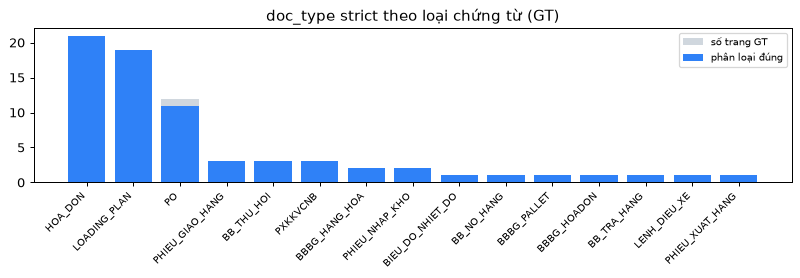

In [7]:
def _cnt(k):
    return round(report[k] * N)
summary = pd.DataFrame([
    {"chỉ số": "doc_type (strict)", "đúng": _cnt("doc_type_accuracy_strict"), "tổng": N, "%": report["doc_type_accuracy_strict"] * 100},
    {"chỉ số": "doc_type (lenient)", "đúng": _cnt("doc_type_accuracy_lenient"), "tổng": N, "%": report["doc_type_accuracy_lenient"] * 100},
    {"chỉ số": "page_role", "đúng": _cnt("page_role_accuracy"), "tổng": N, "%": report["page_role_accuracy"] * 100},
    {"chỉ số": "hệ thống — strict", "đúng": _cnt("system_accuracy"), "tổng": N, "%": report["system_accuracy"] * 100},
    {"chỉ số": "hệ thống — cấp họ (gộp INTERNAL_*)", "đúng": _cnt("system_accuracy_family"), "tổng": N, "%": report["system_accuracy_family"] * 100},
]).round(2)
display(summary)

fm = []
for f, st in report["field_metrics"].items():
    p = st["exact_match"] / st["pred_present"] * 100 if st["pred_present"] else None
    r = st["exact_match"] / st["gt_present"] * 100 if st["gt_present"] else None
    fm.append({"trường": f, "GT có": st["gt_present"], "hệ thống phát": st["pred_present"], "khớp đúng": st["exact_match"],
               "Precision %": None if p is None else round(p, 1), "Recall %": None if r is None else round(r, 1)})
display(pd.DataFrame(fm))

print("Gác cổng:", report["gate_status_distribution"])
print(f"Zone 2: quét {report['zone2_scanned_count']}/{N}, lấp {report['zone2_filled_count']} trường")
print(f"Thời gian phân loại: {report['benchmark_time_sec']:.2f}s ({report['benchmark_time_sec']/N:.2f}s/trang) — phụ thuộc tải máy")

# Độ chính xác doc_type theo từng loại GT
per_type = (eval_df.assign(ok=eval_df.Strict_Match.eq("✅"))
            .groupby("Expected_Doc").agg(so_trang=("ok", "size"), dung=("ok", "sum")))
per_type["%"] = (per_type.dung / per_type.so_trang * 100).round(1)
display(per_type.sort_values("so_trang", ascending=False))

fig, ax = plt.subplots(figsize=(9, 3.2))
pt = per_type.sort_values("so_trang", ascending=False)
ax.bar(pt.index, pt.so_trang, color="#d0d7de", label="số trang GT")
ax.bar(pt.index, pt.dung, color="#2f81f7", label="phân loại đúng")
ax.set_title("doc_type strict theo loại chứng từ (GT)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Bảng lỗi từng ca

Các cột "loại lệch" được suy **cơ học** từ dữ liệu (không có nhãn tự chấm):
- doc_type: nếu Tầng 1 yêu cầu chụp lại → `ABSTAIN_TANG1`; nếu dự đoán `UNKNOWN` → `ABSTAIN_TANG2`; còn lại `NHAM_LOAI`.
- hệ thống: dự đoán `INTERNAL_TRANSFER` trong khi GT là `INTERNAL_KHO_*` → `KHO_KHONG_CO_DAU_HIEU`; khác họ → `KHAC_HO`.
- trường khóa: `SAI_GIA_TRI` (cả hai có, khác nhau) · `PHAT_THUA` (GT rỗng, hệ thống phát) · `BO_SOT` (GT có, hệ thống rỗng).

In [8]:
def _fam(s):
    return "INTERNAL" if s and str(s).startswith("INTERNAL_") else s

doc_err, sys_err, role_err, fld_err = [], [], [], []
for fn in sorted(res_map):
    r, g = res_map[fn], gt_map.get(fn, {})
    s1 = s1_df.loc[fn] if fn in s1_df.index else None
    ev = r.get("evidence", {})
    base = {"file": fn, "sheet": g.get("sheet_origin", ""), "status": r["status"], "conf": r["confidence"], "margin": r["doc_margin"]}
    if r["doc_type"] != g.get("doc_type"):
        kind = ("ABSTAIN_TANG1" if s1 is not None and s1.s1_action == "YEU_CAU_CHUP_LAI"
                else "ABSTAIN_TANG2" if r["doc_type"] == "UNKNOWN" else "NHAM_LOAI")
        doc_err.append({**base, "GT": g.get("doc_type"), "dự đoán": r["doc_type"], "loại lệch": kind,
                        "từ khóa": ev.get("doc_keyword"), "low_res": None if s1 is None else s1.low_resolution,
                        "DPI hiệu dụng": None if s1 is None else s1.effective_dpi,
                        "OCR header (trích)": (r.get("header_text_preview") or "")[:70]})
    if r["system"] != g.get("system"):
        kind = ("KHO_KHONG_CO_DAU_HIEU" if r["system"] == "INTERNAL_TRANSFER" and str(g.get("system", "")).startswith("INTERNAL_KHO")
                else "CUNG_HO_KHAC_LOAI" if _fam(r["system"]) == _fam(g.get("system")) else "KHAC_HO")
        sys_err.append({"file": fn, "doc_type": r["doc_type"], "GT": g.get("system"), "dự đoán": r["system"],
                        "loại lệch": kind, "bằng chứng": ev.get("sys_keyword"), "điểm": ev.get("sys_score")})
    if r["page_role"] != g.get("page_role"):
        role_err.append({"file": fn, "doc_type": r["doc_type"], "GT": g.get("page_role"), "dự đoán": r["page_role"]})
    ef = g.get("expected_fields", {})
    for f in FIELDS:
        e, p = ef.get(f), r["key_fields"].get(f)
        if e is None and p is None:
            continue
        if e is not None and p is not None and str(e).strip() == str(p).strip():
            continue
        kind = "SAI_GIA_TRI" if (e is not None and p is not None) else ("PHAT_THUA" if e is None else "BO_SOT")
        fld_err.append({"file": fn, "doc_type": r["doc_type"], "trường": f, "GT": e, "dự đoán": p, "loại lệch": kind,
                        "zone2": r["zone2_scanned"]})

print(f"### doc_type lệch: {len(doc_err)}/{N}")
display(pd.DataFrame(doc_err))
print(f"### hệ thống lệch (strict): {len(sys_err)}/{N}")
sys_err_df = pd.DataFrame(sys_err)
display(sys_err_df)
if len(sys_err_df):
    print(sys_err_df["loại lệch"].value_counts().to_string())
print(f"### page_role lệch: {len(role_err)}/{N}")
display(pd.DataFrame(role_err) if role_err else "(không có)")
fld_err_df = pd.DataFrame(fld_err)
print(f"### trường khóa lệch: {len(fld_err_df)} ô")
if len(fld_err_df):
    display(fld_err_df.sort_values(["trường", "loại lệch", "file"]))
    display(pd.crosstab(fld_err_df["trường"], fld_err_df["loại lệch"]))

# Gác cổng: mọi trang không DAT
print("### Trang không đạt gác cổng (status != DAT)")
display(eval_df[eval_df.Status != "DAT"][["File", "Expected_Doc", "Pred_Doc", "Status", "Action", "Confidence", "Margin"]])

### doc_type lệch: 1/72
### hệ thống lệch (strict): 9/72
loại lệch
KHAC_HO                  6
KHO_KHONG_CO_DAU_HIEU    3
### page_role lệch: 1/72
### trường khóa lệch: 9 ô
### Trang không đạt gác cổng (status != DAT)


,file,sheet,status,conf,margin,GT,dự đoán,loại lệch,từ khóa,low_res,DPI hiệu dụng,OCR header (trích)
0,PO_3.11__0.png,PO 3.11,CHUA_DAT,0.24,0.0,PO,UNKNOWN,ABSTAIN_TANG2,,True,39.7,"ai , 9 . | My 2 hướn: AS ea có | ene"


,file,doc_type,GT,dự đoán,loại lệch,bằng chứng,điểm
0,BBBGHH_5.1__0.png,BBBG_HANG_HOA,INTERNAL_KHO_THUE,INTERNAL_TRANSFER,KHO_KHONG_CO_DAU_HIEU,NOI BO,1.00
1,BBBGHH_5.2__0.png,BBBG_HANG_HOA,INTERNAL_KHO_NOIBO,INTERNAL_TRANSFER,KHO_KHONG_CO_DAU_HIEU,NOI BO,1.00
2,Hoadon2.2__1.png,HOA_DON,GT,MT_COOP,KHAC_HO,CO.OP,1.00
3,Hoadon2.2__2.png,HOA_DON,GT,MT_WINMART,KHAC_HO,WINCOMMERCE,1.00
4,Hoadon2.2__3.png,HOA_DON,GT,MT_COOP,KHAC_HO,LIEN HIEP HTX,1.00
5,Hoadon_3.3__1.png,HOA_DON,MT_BIGC,GT,KHAC_HO,HOA_DON_DOANH_NGHIEP_GT,0.85
6,PO_3.11__0.png,UNKNOWN,MT_SATRA,COMMON,KHAC_HO,,0.80
7,PXKKVCNB2.3__0.png,PXKKVCNB,GT,INTERNAL_TRANSFER,KHAC_HO,DIEU DONG,1.00
8,PXKKVCNB_5.2__0.png,PXKKVCNB,INTERNAL_KHO_NOIBO,INTERNAL_TRANSFER,KHO_KHONG_CO_DAU_HIEU,DIEU DONG,1.00


,file,doc_type,GT,dự đoán
0,PO_3.11__0.png,UNKNOWN,CONTINUATION,HEADER


,file,doc_type,trường,GT,dự đoán,loại lệch,zone2
5,PO_3.11__0.png,UNKNOWN,po_no,P-000105230,NaN,BO_SOT,False
6,PO_3.4__0.png,PO,po_no,2506260100600123,NaN,BO_SOT,True
7,PO_3.8__0.png,PO,po_no,WE09240510044278,NaN,BO_SOT,True
4,PGH3.6__1.png,PHIEU_GIAO_HANG,po_no,NaN,4171324486,PHAT_THUA,False
8,Phieu_xuat_hang5.1__0.png,PHIEU_XUAT_HANG,pxk_no,0000005,NaN,BO_SOT,True
1,Hoadon2.2__0.png,HOA_DON,shipment_id,128765,NaN,BO_SOT,True
2,Hoadon2.2__1.png,HOA_DON,shipment_id,128765,NaN,BO_SOT,True
3,Hoadon_3.7__0.png,HOA_DON,shipment_id,133870,NaN,BO_SOT,True
0,Hoa_don_3.4__0.png,HOA_DON,shipment_id,2100199210,2100133210,SAI_GIA_TRI,True


loại lệch,BO_SOT,PHAT_THUA,SAI_GIA_TRI
trường,,,
po_no,3,1,0
pxk_no,1,0,0
shipment_id,3,0,1


,File,Expected_Doc,Pred_Doc,Status,Action,Confidence,Margin
49,PGH3.6__0.png,PHIEU_NHAP_KHO,PHIEU_NHAP_KHO,CANH_BAO,CHUYEN_CHUYEN_VIEN_XAC_NHAN,1.00,0.0
53,PO_3.11__0.png,PO,UNKNOWN,CHUA_DAT,CHUYEN_CHUYEN_VIEN_XAC_NHAN,0.24,0.0


Ảnh các ca `doc_type` lệch (ảnh gốc | ảnh Tầng 1 đưa vào Tầng 2) để người kiểm tra tự nhìn nguyên nhân.

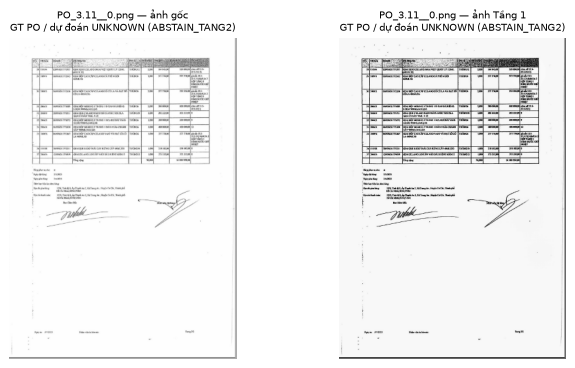

In [9]:
def _thumb(p, w=360):
    im = cv2.imread(str(p)) if p is not None and Path(p).exists() else None
    if im is None:
        return None
    s = w / im.shape[1]
    return cv2.cvtColor(cv2.resize(im, (w, max(1, int(im.shape[0] * s)))), cv2.COLOR_BGR2RGB)

if doc_err:
    fig, axes = plt.subplots(len(doc_err), 2, figsize=(8, 4.2 * len(doc_err)), squeeze=False)
    for i, d in enumerate(doc_err):
        for j, (lbl, p) in enumerate([("ảnh gốc", CFG.samples_dir / d["file"]), ("ảnh Tầng 1", CFG.stage1_images_dir / d["file"])]):
            ax = axes[i][j]
            t = _thumb(p)
            ax.axis("off")
            if t is None:
                ax.text(0.5, 0.5, f"{lbl}: không có ảnh", ha="center", va="center")
            else:
                ax.imshow(t)
            ax.set_title(f"{d['file']} — {lbl}\nGT {d['GT']} / dự đoán {d['dự đoán']} ({d['loại lệch']})", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Không có ca doc_type lệch.")

## 7. Tách loại kho `INTERNAL_KHO_THUE` / `INTERNAL_KHO_NOIBO`

`refine_internal_transfer()` chỉ gán loại kho khi văn bản khớp dấu hiệu của **đúng một** loại
(`config/stage2_keywords.json → internal_subtype_markers`). Không dấu hiệu, hoặc dấu hiệu của cả hai → giữ
`INTERNAL_TRANSFER` (không đoán); Tầng 3 khi đó xếp vào `KHO_CHUA_RO`. Bảng gồm mọi trang mà GT **hoặc**
dự đoán thuộc họ `INTERNAL_*`. Cột `dấu hiệu khớp` lấy từ `evidence.sys_keyword` (phần `SUB:`).

In [10]:
kho_rows = []
for fn in sorted(res_map):
    r, g = res_map[fn], gt_map.get(fn, {})
    if not (str(r["system"]).startswith("INTERNAL_") or str(g.get("system", "")).startswith("INTERNAL_")):
        continue
    kw = str(r.get("evidence", {}).get("sys_keyword") or "")
    kho_rows.append({"file": fn, "doc_type": r["doc_type"], "GT system": g.get("system"), "dự đoán": r["system"],
                     "khớp": "✅" if r["system"] == g.get("system") else "❌",
                     "dấu hiệu khớp": kw.split("SUB:", 1)[1] if "SUB:" in kw else "",
                     "sys_keyword": kw})
kho_df = pd.DataFrame(kho_rows)
display(kho_df)
if len(kho_df):
    display(pd.crosstab(kho_df["GT system"], kho_df["dự đoán"], margins=True))
    n_ok = int((kho_df["khớp"] == "✅").sum())
    print(f"Trang họ chuyển kho: {len(kho_df)} · đúng strict: {n_ok} · "
          f"giữ INTERNAL_TRANSFER vì không có dấu hiệu: {int((kho_df['dự đoán'] == 'INTERNAL_TRANSFER').sum())}")
    wrong_side = kho_df[kho_df["dự đoán"].str.startswith("INTERNAL_KHO") & kho_df["GT system"].str.startswith("INTERNAL_KHO")
                        & (kho_df["dự đoán"] != kho_df["GT system"])]
    print(f"Gán NHẦM loại kho (thuê <-> nội bộ): {len(wrong_side)}  <- lỗi nguy hiểm nhất, phải = 0")

Trang họ chuyển kho: 9 · đúng strict: 5 · giữ INTERNAL_TRANSFER vì không có dấu hiệu: 5
Gán NHẦM loại kho (thuê <-> nội bộ): 0  <- lỗi nguy hiểm nhất, phải = 0


,file,doc_type,GT system,dự đoán,khớp,dấu hiệu khớp,sys_keyword
0,BBBGHH_5.1__0.png,BBBG_HANG_HOA,INTERNAL_KHO_THUE,INTERNAL_TRANSFER,❌,,NOI BO
1,BBBGHH_5.2__0.png,BBBG_HANG_HOA,INTERNAL_KHO_NOIBO,INTERNAL_TRANSFER,❌,,NOI BO
2,Loading_Plan_5.2__0.png,LOADING_PLAN,INTERNAL_KHO_NOIBO,INTERNAL_KHO_NOIBO,✅,BAC NINH,BAC NINH|SUB:BAC NINH
3,Loadingplan_5.1__0.png,LOADING_PLAN,INTERNAL_KHO_THUE,INTERNAL_KHO_THUE,✅,KHO TP THUE,ANPHA|SUB:KHO TP THUE
4,PXKKVCNB2.3__0.png,PXKKVCNB,GT,INTERNAL_TRANSFER,❌,,DIEU DONG
5,PXKKVCNB_5.1__0.png,PXKKVCNB,INTERNAL_KHO_THUE,INTERNAL_KHO_THUE,✅,,DIEU DONG|SUB2:ANPHA
6,PXKKVCNB_5.2__0.png,PXKKVCNB,INTERNAL_KHO_NOIBO,INTERNAL_TRANSFER,❌,,DIEU DONG
7,Phieu_nhap_kho_5.1__0.png,PHIEU_NHAP_KHO,INTERNAL_KHO_THUE,INTERNAL_KHO_THUE,✅,ANPHA,ANPHA|SUB:ANPHA
8,Phieu_xuat_hang5.1__0.png,PHIEU_XUAT_HANG,INTERNAL_TRANSFER,INTERNAL_TRANSFER,✅,,KIDO_SOP_PHIEU_XUAT_HANG


dự đoán,INTERNAL_KHO_NOIBO,INTERNAL_KHO_THUE,INTERNAL_TRANSFER,All
GT system,,,,
GT,0,0,1,1
INTERNAL_KHO_NOIBO,1,0,2,3
INTERNAL_KHO_THUE,0,3,1,4
INTERNAL_TRANSFER,0,0,1,1
All,1,3,5,9


## 8. Các trang `LOADING_PLAN` — đầu vào chính sách chữ ký Tầng 4

Tầng 4 (`tools/stage4_required_policy.py`) chọn bộ vai trò ký **bắt buộc** theo kênh suy từ `system` của Tầng 2
(`config/stage4_lp_required_policy.json → system_to_channel`). Sai `system` ở đây = áp sai chính sách chữ ký.
Bảng gồm mọi trang mà GT **hoặc** dự đoán là `LOADING_PLAN`.

In [11]:
try:
    from tools.stage4_required_policy import load_lp_required_policy, resolve_lp_channel, policy_summary
    LP_POLICY = load_lp_required_policy()
except Exception as exc:  # không im lặng: in rõ và bỏ cột kênh
    LP_POLICY = None
    print(f"⚠️ Không nạp được chính sách chữ ký Tầng 4: {type(exc).__name__}: {exc} -> bỏ qua cột kênh.")

lp_rows = []
for fn in sorted(res_map):
    r, g = res_map[fn], gt_map.get(fn, {})
    if r["doc_type"] != "LOADING_PLAN" and g.get("doc_type") != "LOADING_PLAN":
        continue
    row = {"file": fn, "GT doc": g.get("doc_type"), "dự đoán doc": r["doc_type"],
           "doc ✓": "✅" if r["doc_type"] == g.get("doc_type") else "❌",
           "GT role": g.get("page_role"), "dự đoán role": r["page_role"],
           "GT system": g.get("system"), "dự đoán system": r["system"],
           "system ✓": "✅" if r["system"] == g.get("system") else "❌",
           "status": r["status"], "shipment_id": r["key_fields"].get("shipment_id"),
           "GT shipment": (g.get("expected_fields") or {}).get("shipment_id")}
    if LP_POLICY is not None:
        ch_p, unres_p, why_p = resolve_lp_channel(r["system"], LP_POLICY)
        ch_g, _, _ = resolve_lp_channel(g.get("system"), LP_POLICY)
        row.update({"kênh (dự đoán)": ch_p, "kênh (GT)": ch_g, "kênh ✓": "✅" if ch_p == ch_g else "❌",
                    "kênh chưa phân giải": unres_p, "lý do": why_p,
                    "vai trò bắt buộc (dự đoán)": ", ".join(policy_summary(r["system"], LP_POLICY)["required_roles"])})
    lp_rows.append(row)
lp_df = pd.DataFrame(lp_rows)
display(lp_df)
if len(lp_df):
    n_gt = int((lp_df["GT doc"] == "LOADING_PLAN").sum())
    print(f"Trang LOADING_PLAN theo GT: {n_gt} · dự đoán LOADING_PLAN: {int((lp_df['dự đoán doc'] == 'LOADING_PLAN').sum())}")
    print(f"doc_type đúng: {int((lp_df['doc ✓'] == '✅').sum())}/{len(lp_df)} · system đúng strict: {int((lp_df['system ✓'] == '✅').sum())}/{len(lp_df)}")
    if "kênh ✓" in lp_df:
        print(f"kênh chính sách chữ ký đúng: {int((lp_df['kênh ✓'] == '✅').sum())}/{len(lp_df)} · "
              f"kênh UNRESOLVED (Tầng 4 áp chính sách nghiêm nhất): {int(lp_df['kênh chưa phân giải'].sum())}")
        display(pd.crosstab(lp_df["kênh (GT)"], lp_df["kênh (dự đoán)"], margins=True))

Trang LOADING_PLAN theo GT: 19 · dự đoán LOADING_PLAN: 19
doc_type đúng: 19/19 · system đúng strict: 19/19
kênh chính sách chữ ký đúng: 19/19 · kênh UNRESOLVED (Tầng 4 áp chính sách nghiêm nhất): 0


,file,GT doc,dự đoán doc,doc ✓,GT role,dự đoán role,GT system,dự đoán system,system ✓,status,shipment_id,GT shipment,kênh (dự đoán),kênh (GT),kênh ✓,kênh chưa phân giải,lý do,vai trò bắt buộc (dự đoán)
0,Load3.3__0.png,LOADING_PLAN,LOADING_PLAN,✅,HEADER,HEADER,MT_BIGC,MT_BIGC,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
1,Load_3.11__0.png,LOADING_PLAN,LOADING_PLAN,✅,CONTINUATION,CONTINUATION,MT_SATRA,MT_SATRA,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
2,Load_3.11__1.png,LOADING_PLAN,LOADING_PLAN,✅,HEADER,HEADER,MT_SATRA,MT_SATRA,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
3,Load_3.2__0.png,LOADING_PLAN,LOADING_PLAN,✅,CONTINUATION,CONTINUATION,MT_COOP,MT_COOP,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
4,Load_3.2__1.png,LOADING_PLAN,LOADING_PLAN,✅,HEADER,HEADER,MT_COOP,MT_COOP,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
5,Load_3.5__0.png,LOADING_PLAN,LOADING_PLAN,✅,CONTINUATION,CONTINUATION,MT_AEON,MT_AEON,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
6,Load_3.5__1.png,LOADING_PLAN,LOADING_PLAN,✅,HEADER,HEADER,MT_AEON,MT_AEON,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
7,Load_3.6__0.png,LOADING_PLAN,LOADING_PLAN,✅,CONTINUATION,CONTINUATION,MT_WINMART,MT_WINMART,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
8,Load_3.6__1.png,LOADING_PLAN,LOADING_PLAN,✅,HEADER,HEADER,MT_WINMART,MT_WINMART,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"
9,Load_3.7__0.png,LOADING_PLAN,LOADING_PLAN,✅,HEADER,HEADER,MT_EMART,MT_EMART,✅,DAT,NaN,NaN,MT,MT,✅,False,PREFIX(MT_),"Tài xế (Lái xe nhận hàng), Người giao / Thủ kho xuất"


kênh (dự đoán),KHO_NOIBO,KHO_THUE,MT,NPP,All
kênh (GT),,,,,
KHO_NOIBO,1,0,0,0,1
KHO_THUE,0,1,0,0,1
MT,0,0,14,0,14
NPP,0,0,0,3,3
All,1,1,14,3,19


## 9. Hợp đồng artifact

Liệt kê file đã ghi, quét mã nguồn `tools/` để thấy **tầng nào đọc file nào** (đo, không khai báo tay), và —
nếu đây là lần chạy thử — so DIFF từng ảnh với artifact chính thức (bỏ `elapsed_ms`, bỏ `benchmark_time_sec`).

In [12]:
import re as _re
for p in sorted(OUT_DIR.glob("stage2_*")):
    print(f"  {p.name:<34} {p.stat().st_size/1024:8.1f} KB  {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(p.stat().st_mtime))}")

readers = []
for src in sorted(Path("tools").glob("*.py")):
    if src.name in ("run_full_benchmark_and_save.py", "generate_nb2.py", "run_and_populate_nb2.py"):
        continue
    txt = src.read_text(encoding="utf-8", errors="replace")
    for name in ("stage2_classified_results.json", "stage2_benchmark_report.json", "stage2_evaluation.csv"):
        if _re.search(r"stage2_out[/\\\\]+" + _re.escape(name), txt):
            readers.append({"file đọc": name, "module": src.name})
display(pd.DataFrame(readers))
from tools.stage3_resolver import DEFAULT_STAGE2_JSON_PATH
print(f"Tầng 3 (stage3_resolver.DEFAULT_STAGE2_JSON_PATH) = {DEFAULT_STAGE2_JSON_PATH}")
print(f"Notebook ghi                                    = {OUT_DIR / 'stage2_classified_results.json'}")
print("=> trùng file Tầng 3 đọc" if (OUT_DIR / "stage2_classified_results.json").resolve() == Path(DEFAULT_STAGE2_JSON_PATH).resolve()
      else "=> CHẠY THỬ: Tầng 3/4 KHÔNG đọc file này")

if not IS_OFFICIAL_RUN:
    off = OFFICIAL_OUT_DIR / "stage2_classified_results.json"
    if not off.exists():
        print(f"Không có artifact chính thức để so: {off}")
    else:
        a = {r["file_name"]: r for r in json.loads(off.read_text(encoding="utf-8"))}
        b = {r["file_name"]: r for r in results}
        diffs = []
        for fn in sorted(set(a) | set(b)):
            x, y = a.get(fn), b.get(fn)
            if x is None or y is None:
                diffs.append({"file": fn, "khóa": "<thiếu bản ghi>", "chính thức": x is not None, "lần này": y is not None})
                continue
            for k in sorted(set(x) | set(y) - {"elapsed_ms"}):
                if k != "elapsed_ms" and x.get(k) != y.get(k):
                    diffs.append({"file": fn, "khóa": k, "chính thức": x.get(k), "lần này": y.get(k)})
        rep_off = json.loads((OFFICIAL_OUT_DIR / "stage2_benchmark_report.json").read_text(encoding="utf-8"))
        rep_diff = {k: (rep_off.get(k), report.get(k)) for k in set(rep_off) | set(report)
                    if k != "benchmark_time_sec" and rep_off.get(k) != report.get(k)}
        print(f"DIFF từng ảnh với artifact chính thức: {len(diffs)} khác biệt ({len({d['file'] for d in diffs})} ảnh)")
        print(f"DIFF report (bỏ thời gian): {rep_diff or 0}")
        if diffs:
            display(pd.DataFrame(diffs))
        print("KẾT LUẬN:", "DIFF = 0" if not diffs and not rep_diff else "CÓ LỆCH — xem bảng trên")

  stage2_benchmark_report.json            1.5 KB  2026-09-28 00:40:25
  stage2_classified_results.json         81.9 KB  2026-09-28 00:40:25
  stage2_evaluation.csv                  11.2 KB  2026-09-28 00:40:25
Tầng 3 (stage3_resolver.DEFAULT_STAGE2_JSON_PATH) = output/stage2_out/stage2_classified_results.json
Notebook ghi                                    = output\stage2_out\stage2_classified_results.json
=> trùng file Tầng 3 đọc


,file đọc,module
0,stage2_classified_results.json,build_lp_dynamic_crops.py
1,stage2_classified_results.json,generate_nb3_ver2.py
2,stage2_classified_results.json,generate_nb4_ver2.py
3,stage2_benchmark_report.json,generate_nb_e2e.py
4,stage2_classified_results.json,lp_production_path.py
5,stage2_classified_results.json,stage3_resolver.py
6,stage2_classified_results.json,test_lp_missing_signature.py
7,stage2_classified_results.json,test_stage3_suite.py


## 10. Test bất biến tên file (`tools/test_stage2_filename_invariance.py`)

Đổi tên toàn bộ ảnh thành `UP_<hex>.png` ngẫu nhiên (copy vào `scratch/`), đổi cả `upload_group_id` sang id
ngẫu nhiên, giữ nguyên mapping nhóm/thứ tự trang; OCR lại **thật** bộ tên mới và so từng trang với bộ tên gốc
(kết quả mục 4) ở 3 mức: trước vote, vote theo nhóm, không nhóm — phải **DIFF = 0**.
Kèm **đối chứng dương**: một bộ vote cố ý nhóm theo tên file (đúng cơ chế cũ) phải cho DIFF > 0, để chứng
minh phép so thật sự phát hiện được phụ thuộc tên file. Tắt bằng `STAGE2_NB_SKIP_INVARIANCE=1`.

In [13]:
if not RUN_INVARIANCE:
    print("Bỏ qua (STAGE2_NB_SKIP_INVARIANCE=1) — KHÔNG có kết luận bất biến trong lần chạy này.")
elif UPLOAD_GROUPS_PATH is None:
    print("Bỏ qua: cần metadata upload để kiểm chế độ có nhóm.")
else:
    from tools.test_stage2_filename_invariance import run as run_invariance
    inv_ok, inv = run_invariance(stage1_dir=STAGE1_DIR, work_dir=INVARIANCE_WORK_DIR,
                                 upload_groups_path=UPLOAD_GROUPS_PATH, raw_original=bench["raw_results"], verbose=False)
    display(pd.DataFrame([{"mức so": k, "DIFF": v, "kết quả": "PASS" if v == 0 else "FAIL"} for k, v in inv["checks"].items()]
                         + [{"mức so": "đối chứng dương (vote theo tên file)", "DIFF": inv["positive_control_pages"],
                             "kết quả": "PASS" if inv["positive_control_pages"] > 0 else "FAIL"}]))
    assert inv_ok, "Tầng 2 KHÔNG bất biến với tên file"

Bộ tên GỐC: dùng kết quả truyền vào (72 trang)
Bộ tên MỚI: 72 ảnh -> scratch\_stage2_invariance (vd BBBGHH_5.1__0.png -> UP_e796e4a99857.png); phân loại...
  xong 240.5s

=== BẤT BIẾN TÊN FILE ===
  [PASS] trước vote (classify_document)  : DIFF = 0 (0 trang)
  [PASS] vote theo upload_group          : DIFF = 0 (0 trang)
  [PASS] không nhóm (không vote)         : DIFF = 0 (0 trang)
  [PASS] đối chứng dương (vote theo tên)  : 8 trang đổi KẾT QUẢ NGHIỆP VỤ khi đổi tên (phải > 0)

=== CHỈ SỐ (tên gốc) — có nhóm upload vs không nhóm ===
  chế độ=upload_group | doc_type=98.61 | page_role=98.61 | sys strict=87.50 | sys họ=91.67 | gate={'DAT': 70, 'CANH_BAO': 1, 'CHUA_DAT': 1} | shipment_id=P95.7/R84.6 (22/23/26) | invoice_no=P100.0/R100.0 (21/21/21) | po_no=P90.0/R75.0 (9/10/12) | pxk_no=P100.0/R75.0 (3/3/4) | transfer_order_no=P100.0/R100.0 (3/3/3)
  chế độ=không nhóm | doc_type=98.61 | page_role=98.61 | sys strict=77.78 | sys họ=81.94 | gate={'DAT': 70, 'CANH_BAO': 1, 'CHUA_DAT': 1} | shipme

,mức so,DIFF,kết quả
0,trước vote (classify_document),0,PASS
1,vote theo upload_group,0,PASS
2,không nhóm (không vote),0,PASS
3,đối chứng dương (vote theo tên file),8,PASS
